# <span style="color:#c8b6ff">**Traduction en PyTorch**</span>

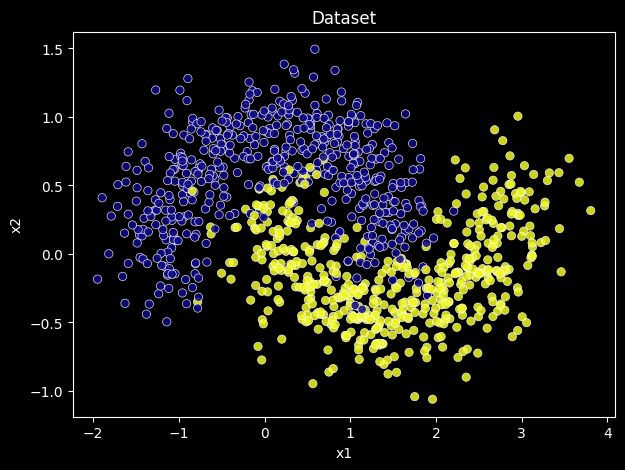

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os #noqa
proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # ajuster le chemin si nécessaire
if proj_root not in sys.path:
    sys.path.insert(0, proj_root) 

from modules.utils import create_moons_dataset # noqa

X, y = create_moons_dataset(n_samples=1000, noise=0.25, rotate_deg=2, as_dataframe=False)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
plt.style.use("dark_background")
plt.figure(figsize=(7, 5))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap="plasma",
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset")
plt.show()

### Le tensor

Voir [Data Analysis Python Init](https://github.com/aurvl/AI-Step-by-Step/blob/main/bp1-linear-regression/0_python_stats_data_analysis_foundations.ipynb) pour plus de détails

In [2]:
import torch
# ======================================================
# Le tensor, c’est l’objet de base de PyTorch.
# C’est l’équivalent "deep learning" du tableau NumPy.
# ======================================================
# torch.tensor(...)
X_torch = torch.tensor(X, device='cpu', dtype=torch.float32)
print("X transformé en tensor")
print(X_torch)
print()

# .shape
print("Shape de X_torch : ", X_torch.shape)
print("Dimensions du X_tensor :", X_torch.ndim)

# .dtype
print("Type du tensor", X_torch.dtype)
print()

# .float()
t = torch.tensor([1, 2, 3], dtype=torch.int64)
t2 = t.float()           # dtype torch.float32
t3 = t.to(torch.float32) # équivalent
print(t)
print(t2)
print(t3)

X transformé en tensor
tensor([[-0.0598,  0.4733],
        [ 1.7763, -0.2822],
        [ 1.1709,  0.0905],
        ...,
        [ 2.5256, -0.4130],
        [-1.2530, -0.0315],
        [ 1.1645,  0.5968]])

Shape de X_torch :  torch.Size([1000, 2])
Dimensions du X_tensor : 2
Type du tensor torch.float32

tensor([1, 2, 3])
tensor([1., 2., 3.])
tensor([1., 2., 3.])


### Trainable parameters

In [3]:
# ============================================================
# 1) Créer un tensor "normal"
# ============================================================
# Ici, x est juste une valeur stockée dans un tensor.
# PyTorch peut faire des calculs avec, mais ne suivra pas
# automatiquement les gradients.
x = torch.tensor(3.0)
print("x =", x)
print("x.requires_grad =", x.requires_grad)

# ============================================================
# 2) Créer un tensor avec requires_grad=True
# ============================================================
# Ici, on dit explicitement à PyTorch :
# "je veux suivre tous les calculs faits à partir de ce tensor,
# pour pouvoir dériver ensuite automatiquement."
w = torch.tensor(2.0, requires_grad=True)
print("\nw =", w)
print("w.requires_grad =", w.requires_grad)

# ============================================================
# 3) Faire un calcul différentiable
# ============================================================
# On construit une petite fonction :
# ys = w^2 + 3w + 1
#
# Comme w a requires_grad=True, PyTorch construit en arrière-plan
# le graphe de calcul qui permettra de dériver ys par rapport à w.
ys = w**2 + 3*w + 1
print("\ny =", ys)

# ============================================================
# 4) Lancer la rétropropagation
# ============================================================
# backward() demande à PyTorch :
# "calcule la dérivée de ys par rapport à tous les tensors
# qui ont requires_grad=True et qui ont servi à produire ys"
ys.backward()

# ============================================================
# 5) Lire le gradient
# ============================================================
# Le gradient calculé est stocké dans .grad
# Ici :
# ys = w^2 + 3w + 1
# donc dy/dw = 2w + 3
# si w = 2, alors dy/dw = 7
print("Gradient de ys par rapport à w :", w.grad)

x = tensor(3.)
x.requires_grad = False

w = tensor(2., requires_grad=True)
w.requires_grad = True

y = tensor(11., grad_fn=<AddBackward0>)
Gradient de ys par rapport à w : tensor(7.)


### Backward

In [4]:
# Ici, on crée un vecteur de "poids"
W = torch.tensor([1.0, -2.0, 3.0], requires_grad=True)
print("W =", W)

# On construit une quantité finale scalaire pour pouvoir appeler backward()
# Ici on somme les carrés
L = torch.sum(W**2)

# Backward
L.backward()

# Gradient
# Si L = w1^2 + w2^2 + w3^2
# alors dL/dW = [2w1, 2w2, 2w3]
print("Gradient stocké dans W.grad =", W.grad)

W = tensor([ 1., -2.,  3.], requires_grad=True)
Gradient stocké dans W.grad = tensor([ 2., -4.,  6.])


Avant, on calculait les gradients à la main.</br>Avec `requires_grad=True`, PyTorch sait maintenant suivre automatiquement les opérations et stocker les gradients après `backward()`.

### Linear

Jusqu’ici, on écrivait nos transformations linéaires à la main :

$$
Z = XW + b
$$

Dans PyTorch, cette opération existe déjà sous la forme d’une couche prête à l’emploi :

```python
nn.Linear(in_features, out_features)
```

C’est ce qu’on appelle une **couche dense** ou **fully connected layer**.

### Comment la lire ?

* `in_features` = nombre de variables en entrée
* `out_features` = nombre de neurones dans la couche

Autrement dit :

* `nn.Linear(2, 1)` correspond à un neurone qui reçoit 2 entrées et produit 1 sortie
* `nn.Linear(2, 3)` correspond à une couche de 3 neurones recevant 2 entrées

Ce que PyTorch automatise ici, c’est exactement ce que nous faisions à la main :

* initialiser les poids ;
* initialiser les biais ;
* calculer la transformation linéaire.

> `nn.Linear` est donc la version PyTorch de la brique mathématique fondamentale :
> **agréger des entrées avec des poids et un biais**.

C’est la même idée que :

* la régression linéaire ;
* le perceptron simple ;
* ou plus généralement une couche dense dans un réseau de neurones.

In [5]:
import torch.nn as nn

# ============================================================
# 1) Créer une couche linéaire
# ============================================================
# Ici :
# - 2 entrées
# - 3 sorties
# Donc PyTorch crée automatiquement :
# - une matrice de poids
# - un vecteur de biais
linear = nn.Linear(in_features=2, out_features=3)

print("Couche :", linear)

# ============================================================
# 2) Créer un petit batch d'entrée
# ============================================================
# Ici on a 4 observations, chacune avec 2 features
D = torch.tensor([
    [1.0, 2.0],
    [0.5, -1.0],
    [3.0, 0.0],
    [-2.0, 1.5]
], dtype=torch.float32)

print("\nX shape :", D.shape)

# ============================================================
# 3) Faire passer le batch dans la couche
# ============================================================
# PyTorch applique automatiquement :
# Z = XW + b
Z = linear(D)

print("\nSortie Z :")
print(Z)
print("Z shape :", Z.shape)

# ============================================================
# 4) Regarder les paramètres appris
# ============================================================
# La couche contient déjà ses paramètres :
# - weight
# - bias
print("\nPoids (weight) :")
print(linear.weight)
print("Shape weight :", linear.weight.shape)

print("\nBiais (bias) :")
print(linear.bias)
print("Shape bias :", linear.bias.shape)


Couche : Linear(in_features=2, out_features=3, bias=True)

X shape : torch.Size([4, 2])

Sortie Z :
tensor([[ 0.0469,  0.4296, -1.1048],
        [ 0.4065, -0.3179,  0.5435],
        [ 1.1137, -0.0280,  0.0138],
        [-0.9270,  0.2542, -0.8547]], grad_fn=<AddmmBackward0>)
Z shape : torch.Size([4, 3])

Poids (weight) :
Parameter containing:
tensor([[ 0.3545, -0.1789],
        [ 0.0174,  0.2463],
        [ 0.0084, -0.5508]], requires_grad=True)
Shape weight : torch.Size([3, 2])

Biais (bias) :
Parameter containing:
tensor([ 0.0503, -0.0803, -0.0115], requires_grad=True)
Shape bias : torch.Size([3])


In [6]:
# Backward de cette couche Linear
# Pour faire backward(), il faut une sortie finale scalaire.
# Ici on prend juste la somme des carrés, pour illustrer.
loss = torch.sum(Z**2)

print("Loss =", loss.item())
print()

print("Gradients avant la backward :")
print(linear.weight.grad)
print(linear.bias.grad)
print("Aucun gradients")

# PyTorch calcule automatiquement les gradients de la loss
# par rapport à tous les paramètres différentiables de la couche.
loss.backward()

# Lire les gradients
print("\nGradient des poids :")
print(linear.weight.grad)
print("Shape gradient weight :", linear.weight.grad.shape)

print("\nGradient des biais :")
print(linear.bias.grad)
print("Shape gradient bias :", linear.bias.grad.shape)

Loss = 4.864706993103027

Gradients avant la backward :
None
None
Aucun gradients

Gradient des poids :
tensor([[10.8903, -3.4066],
        [-0.6437,  3.1170],
        [ 1.8353, -8.0702]])
Shape gradient weight : torch.Size([3, 2])

Gradient des biais :
tensor([ 1.2799,  0.6760, -2.8042])
Shape gradient bias : torch.Size([3])


### Un neurone avec `Linear`

On peut maintenant recréer, en PyTorch, le neurone artificiel que l’on a construit à la main plus haut.

L’idée est la même :

- une couche linéaire agrège les entrées ;
- elle produit un score ;
- puis on peut lui ajouter une fonction d’activation.

Avant cela, il faut simplement convertir les données du dataset en **tensors PyTorch**, car le framework ne travaille pas directement avec les tableaux NumPy dans le calcul différentiable.

In [7]:
# X et y viennent du dataset déjà préparé plus haut
# Ici on les convertit en tensors PyTorch

X_tensor = torch.from_numpy(X).float() # convert nos numpy data en tensor
y_tensor = torch.from_numpy(y).float().reshape(-1, 1)

print("X_tensor shape :", X_tensor.shape)
print("y_tensor shape :", y_tensor.shape)
print("X_tensor dtype :", X_tensor.dtype)
print("y_tensor dtype :", y_tensor.dtype)

X_tensor shape : torch.Size([1000, 2])
y_tensor shape : torch.Size([1000, 1])
X_tensor dtype : torch.float32
y_tensor dtype : torch.float32


In [8]:
# Un neurone : p entrées -> 1 sortie
neuron = nn.Linear(in_features=X_tensor.shape[1], out_features=1)

# Score linéaire produit par le neurone
z = neuron(X_tensor)

print("z shape :", z.shape)
print(z[:5])

z shape : torch.Size([1000, 1])
tensor([[-0.1257],
        [ 1.3942],
        [ 0.8241],
        [ 0.6415],
        [-0.6406]], grad_fn=<SliceBackward0>)


In [9]:
# Ajout d'une activation sigmoïde
y_hat = torch.sigmoid(z)

print("y_hat shape :", y_hat.shape)
print(y_hat[:5])

y_hat shape : torch.Size([1000, 1])
tensor([[0.4686],
        [0.8013],
        [0.6951],
        [0.6551],
        [0.3451]], grad_fn=<SliceBackward0>)


On retrouve exactement la logique déjà vue :

- `nn.Linear(...)` joue le rôle de la partie linéaire ;
- `torch.sigmoid(...)` joue le rôle de l’activation ;
- la sortie `y_hat` peut maintenant être interprétée comme une probabilité dans un cadre binaire.

Autrement dit, PyTorch nous permet de reconstruire le perceptron complet avec très peu de code.

In [10]:
# Loss
# Comme on est en classification binaire avec une sortie sigmoid,
# on peut utiliser BCELoss (Binary Cross Entropy Loss).
criterion = nn.BCELoss()

loss = criterion(y_hat, y_tensor)
print("Loss :", loss.item())

Loss : 0.5134457349777222


In [11]:
# Backward
# Avant backward, les gradients sont encore vides
print("Gradients avant backward :")
print("weight.grad =", neuron.weight.grad)
print("bias.grad   =", neuron.bias.grad)

# Ici PyTorch calcule automatiquement tous les gradients
loss.backward()

print("\nGradients après backward :")
print("weight.grad =", neuron.weight.grad)
print("bias.grad =", neuron.bias.grad)

Gradients avant backward :
weight.grad = None
bias.grad   = None

Gradients après backward :
weight.grad = tensor([[-0.0353,  0.1382]])
bias.grad = tensor([0.1141])


In [12]:
# Update manuel
# On met à jour les paramètres "à la main", comme on le faisait plus haut.
learning_rate = 0.01

with torch.no_grad(): # Désactivation du calcul des gradients (pour gagner en mémoire et vitesse)
    neuron.weight -= learning_rate * neuron.weight.grad
    neuron.bias   -= learning_rate * neuron.bias.grad

print("Poids mis à jour :")
print(neuron.weight)
print()
print("Biais mis à jour :")
print(neuron.bias)

Poids mis à jour :
Parameter containing:
tensor([[ 0.5986, -0.5591]], requires_grad=True)

Biais mis à jour :
Parameter containing:
tensor([0.1729], requires_grad=True)


In [13]:
# Remise à zéro des gradients
# Très important : PyTorch accumule les gradients.
# Donc avant une nouvelle itération, il faut les remettre à zéro.
neuron.weight.grad.zero_()
neuron.bias.grad.zero_()

print("Gradients après remise à zéro :")
print("weight.grad =", neuron.weight.grad)
print("bias.grad   =", neuron.bias.grad)

Gradients après remise à zéro :
weight.grad = tensor([[0., 0.]])
bias.grad   = tensor([0.])


### Opérations tensorielles

PyTorch manipule des **tensors**, qui jouent le même rôle que les tableaux NumPy dans nos implémentations précédentes.
La différence est qu’ils s’intègrent directement dans le calcul différentiable.
On va donc retrouver les mêmes opérations qu’avant :

* produit matriciel ;
* addition du biais ;
* changement de shape ;
* opérations élément par élément.


In [14]:
# ============================================================
# Créer deux tensors
# ============================================================
# Ici :
# - X = dataset

# W représente une matrice de poids :
# - 2 entrées
# - 3 sorties
W = torch.randn(2, 3, dtype=torch.float32)

# b représente un biais pour chaque sortie
b = torch.randn(3, dtype=torch.float32) # généralement on met des zeros : torch.zeros(3, dtype)

print("X shape :", X_tensor.shape)   # (3, 2)
print("W shape :", W.shape)   # (2, 3)
print("b shape :", b.shape)   # (3,)


X shape : torch.Size([1000, 2])
W shape : torch.Size([2, 3])
b shape : torch.Size([3])


In [15]:
# ============================================================
# Produit matriciel
# ============================================================
# On retrouve exactement la logique vue précédemment :
# Z = XW + b
#
# Le produit matriciel se fait avec l'opérateur @
Z = X_tensor @ W

print("\nZ sans biais =")
print(Z)
print("Z shape =", Z.shape)   # (3, 3)

# ============================================================
# Broadcasting du biais
# ============================================================
# Ici, PyTorch ajoute automatiquement le vecteur b à chaque ligne de Z.
# Ce mécanisme s'appelle le broadcasting.
Z_bias = Z + b

print("\nZ avec biais =")
print(Z_bias)
print("Z_bias shape =", Z_bias.shape)



Z sans biais =
tensor([[-0.1126,  0.3166,  0.4231],
        [ 2.5269, -2.3803, -0.9500],
        [ 1.6492, -1.4280, -0.3931],
        ...,
        [ 3.5935, -3.3903, -1.3606],
        [-1.7687,  1.5614,  0.4757],
        [ 1.6102, -1.1618,  0.0364]])
Z shape = torch.Size([1000, 3])

Z avec biais =
tensor([[ 0.5181,  1.1656,  0.5689],
        [ 3.1575, -1.5312, -0.8041],
        [ 2.2798, -0.5790, -0.2473],
        ...,
        [ 4.2241, -2.5413, -1.2148],
        [-1.1381,  2.4104,  0.6215],
        [ 2.2408, -0.3128,  0.1822]])
Z_bias shape = torch.Size([1000, 3])


In [16]:
# ============================================================
# Opérations élément par élément
# ============================================================
# Comme avec NumPy, on peut faire des opérations directement
# sur tous les éléments d'un tensor.
Z_squared = Z_bias ** 2
print("\nCarré élément par élément =")
print(Z_squared)

# ============================================================
# Changer la forme d'un tensor
# ============================================================
# reshape permet de modifier la structure d'un tensor
# sans changer ses valeurs.
ys = torch.tensor([1.0, 0.0, 1.0], dtype=torch.float32)

print("\ny shape avant reshape :", ys.shape)   # (3,)
ys = ys.reshape(-1, 1)
print("ys shape après reshape :", ys.shape)     # (3, 1)

# ============================================================
# Réductions
# ============================================================
# On peut résumer un tensor avec des opérations comme :
# - sum
# - mean
# - max
print("\nSomme totale :", torch.sum(Z_bias))
print("Moyenne totale :", torch.mean(Z_bias))
print("Max global :", torch.max(Z_bias))



Carré élément par élément =
tensor([[ 0.2684,  1.3587,  0.3236],
        [ 9.9699,  2.3446,  0.6467],
        [ 5.1977,  0.3352,  0.0611],
        ...,
        [17.8431,  6.4580,  1.4757],
        [ 1.2952,  5.8102,  0.3863],
        [ 5.0213,  0.0978,  0.0332]])

y shape avant reshape : torch.Size([3])
ys shape après reshape : torch.Size([3, 1])

Somme totale : tensor(1689.6896)
Moyenne totale : tensor(0.5632)
Max global : tensor(5.9895)


### Fonctions d’activation + loss functions PyTorch

Dans nos implémentations from scratch, on appliquait une activation après la partie linéaire, puis on calculait une loss adaptée au problème.
PyTorch fournit déjà ces briques.
L’idée ne change donc pas :

* transformation linéaire ;
* activation ;
* comparaison entre prédiction et vérité terrain.

In [17]:
# ============================================================
# Exemple d'activations PyTorch
# ============================================================
# On crée un petit vecteur de scores pour illustrer
z = torch.tensor([[-2.0, -0.4, 0.5, 3.0]], dtype=torch.float32)

# ReLU : coupe les valeurs négatives
relu_out = torch.relu(z)

# Sigmoid : ramène les valeurs entre 0 et 1
sigmoid_out = torch.sigmoid(z)

# Tanh : ramène les valeurs entre -1 et 1
tanh_out = torch.tanh(z)

print("z =")
print(z)

print("\nReLU(z) =")
print(relu_out)

print("\nSigmoid(z) =")
print(sigmoid_out)

print("\nTanh(z) =")
print(tanh_out)


z =
tensor([[-2.0000, -0.4000,  0.5000,  3.0000]])

ReLU(z) =
tensor([[0.0000, 0.0000, 0.5000, 3.0000]])

Sigmoid(z) =
tensor([[0.1192, 0.4013, 0.6225, 0.9526]])

Tanh(z) =
tensor([[-0.9640, -0.3799,  0.4621,  0.9951]])


In [18]:
# ============================================================
# Loss pour une régression : MSELoss
# ============================================================
# Ici on illustre la MSE, adaptée aux sorties continues.
y_pred_reg = torch.tensor([[2.5], [0.3], [1.8]], dtype=torch.float32)
y_true_reg = torch.tensor([[3.0], [0.0], [2.0]], dtype=torch.float32)

mse_loss = nn.MSELoss()
loss_reg = mse_loss(y_pred_reg, y_true_reg)

print("MSE Loss =", loss_reg.item())

# ============================================================
# Loss pour une classification binaire : BCELoss
# ============================================================
# Ici la sortie du modèle est déjà passée par une sigmoid,
# donc elle représente des probabilités entre 0 et 1.
y_pred_bin = torch.tensor([[0.9], [0.2], [0.7]], dtype=torch.float32)
y_true_bin = torch.tensor([[1.0], [0.0], [1.0]], dtype=torch.float32)

bce_loss = nn.BCELoss()
loss_bin = bce_loss(y_pred_bin, y_true_bin)

print("BCE Loss =", loss_bin.item())

# ============================================================
# Version plus stable numériquement : BCEWithLogitsLoss
# ============================================================
# Très important :
# cette loss attend des scores bruts (logits), sans sigmoid appliquée avant.
#
# C'est souvent la meilleure pratique en classification binaire.
logits = torch.tensor([[2.2], [-1.4], [0.8]], dtype=torch.float32)
targets = torch.tensor([[1.0], [0.0], [1.0]], dtype=torch.float32)

bce_logits_loss = nn.BCEWithLogitsLoss()
loss_logits = bce_logits_loss(logits, targets)

print("BCEWithLogitsLoss =", loss_logits.item())

MSE Loss = 0.12666667997837067
BCE Loss = 0.22839301824569702
BCEWithLogitsLoss = 0.23220045864582062


**Pourquoi BCEWithLogitsLoss est utile ?**

Elle combine *la sigmoid* et *la binary cross entropy* dans une seule opération plus stable numériquement.

Donc :
- BCELoss -> si tu as déjà des probabilités
- BCEWithLogitsLoss -> si ton modèle sort encore des scores bruts

### `nn.Sequential`

`nn.Sequential` permet d’empiler des couches et des activations dans l’ordre.
C’est la façon la plus simple de construire rapidement un petit réseau.
Autrement dit, c’est une traduction directe du MLP que nous avons codé à la main :

* couche ;
* activation ;
* couche ;
* activation.

In [19]:
# ============================================================
# 1) Construire un petit réseau avec nn.Sequential
# ============================================================
# Ici, on crée un MLP très simple :
#
# - entrée de dimension 2
# - couche cachée de 4 neurones
# - activation ReLU
# - couche de sortie de 1 neurone
# - activation Sigmoid pour une sortie binaire
model = nn.Sequential(
    nn.Linear(2, 4),   # couche dense : 2 entrées -> 4 neurones
    nn.ReLU(),         # activation appliquée à la sortie précédente
    nn.Linear(4, 1),   # couche dense : 4 entrées -> 1 sortie
    nn.Sigmoid()       # transforme le score final en probabilité
)

print(model)

# ============================================================
# 2) Faire passer les données dans tout le réseau
# ============================================================
# Avec Sequential, on n'appelle pas chaque couche à la main.
# PyTorch applique automatiquement chaque bloc dans l'ordre.
y_hat = model(X_tensor)

print("\nSortie du réseau =")
print(y_hat[:5])
print("y_hat shape :", y_hat.shape)

# ============================================================
# 3) Lire une couche particulière
# ============================================================
# Sequential stocke les blocs dans l'ordre :
# model[0] = première couche linéaire
# model[1] = ReLU
# model[2] = deuxième couche linéaire
# model[3] = Sigmoid
print("\nPremière couche :", model[0])
print("Dernière couche linéaire :", model[2])

# ============================================================
# 4) Accéder aux paramètres
# ============================================================
# Chaque couche linéaire possède ses propres poids et biais.
print("\nPoids de la première couche :")
print(model[0].weight)
print("Shape :", model[0].weight.shape)

print("\nBiais de la première couche :")
print(model[0].bias)
print("Shape :", model[0].bias.shape)

# ============================================================
# Lecture conceptuelle
# ============================================================
# Ce modèle correspond à :
#
# X
# -> Linear(2,4)
# -> ReLU
# -> Linear(4,1)
# -> Sigmoid
#
# Donc on retrouve exactement :
# - une couche cachée
# - une activation
# - une couche de sortie
# - une activation finale binaire


Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Sortie du réseau =
tensor([[0.3506],
        [0.3107],
        [0.3191],
        [0.3722],
        [0.3717]], grad_fn=<SliceBackward0>)
y_hat shape : torch.Size([1000, 1])

Première couche : Linear(in_features=2, out_features=4, bias=True)
Dernière couche linéaire : Linear(in_features=4, out_features=1, bias=True)

Poids de la première couche :
Parameter containing:
tensor([[ 0.3849,  0.1265],
        [ 0.1444,  0.4187],
        [-0.4006, -0.1250],
        [ 0.1053,  0.2443]], requires_grad=True)
Shape : torch.Size([4, 2])

Biais de la première couche :
Parameter containing:
tensor([ 0.4884,  0.0916,  0.0393, -0.2568], requires_grad=True)
Shape : torch.Size([4])


### `nn.Module`

Quand le réseau devient un peu plus sérieux, `nn.Sequential` peut devenir trop limité.
Dans ce cas, on définit une **classe PyTorch** qui hérite de `nn.Module`.
Une classe permet de regrouper :

* les couches du modèle ;
* la logique du forward ;
* et plus tard d’ajouter davantage de contrôle.


In [22]:
# ============================================================
# Définir une classe de modèle
# ============================================================
# En PyTorch, un vrai modèle est très souvent une classe
# qui hérite de nn.Module.
#
# Pourquoi ?
# Parce qu'on veut :
# - définir les couches dans __init__
# - définir la logique du passage avant dans forward()
# et nn.Module contient cette logique (dont va hériter notre class)
class SimpleMLP(nn.Module):
    # Initialisation de la classe (le constructeur): On définit tout ici
    def __init__(self, input_dim, hidden_dim, output_dim):
        # super().__init__() initialise correctement la classe parente nn.Module
        # C'est indispensable pour que PyTorch enregistre les couches et paramètres.
        super().__init__()

        # Première couche linéaire : entrée -> couche cachée
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Deuxième couche linéaire : couche cachée -> sortie
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    # méthode/fonction qui définit comment les données traversent le modèle(forward prop). 
    def forward(self, x):
        # 1) transformation linéaire
        x = self.fc1(x)

        # 2) activation non linéaire
        x = torch.relu(x)

        # 3) couche de sortie
        x = self.fc2(x)

        # 4) activation finale
        x = torch.sigmoid(x)

        # Le résultat final est retourné
        return x

# ============================================================
# Instancier le modèle
# ============================================================
model = SimpleMLP(input_dim=2, hidden_dim=16, output_dim=1)
print(model)

# ============================================================
# Forward du modèle
# ============================================================
# Appeler model(X) déclenche automatiquement model.forward(X)
y_hat = model(X_tensor)

print("\nSortie du modèle :")
print(y_hat[:5])
print("y_hat shape :", y_hat.shape)

# ============================================================
# 5) Paramètres du modèle
# ============================================================
# parameters() permet d'accéder à tous les poids et biais entraînables.
print("\nListe des paramètres :")
for p in model.parameters():
    print(p.shape)


SimpleMLP(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Sortie du modèle :
tensor([[0.5039],
        [0.5285],
        [0.5113],
        [0.5000],
        [0.4831]], grad_fn=<SliceBackward0>)
y_hat shape : torch.Size([1000, 1])

Liste des paramètres :
torch.Size([16, 2])
torch.Size([16])
torch.Size([1, 16])
torch.Size([1])


### Optimizer

Dans nos implémentations from scratch, on mettait à jour les poids à la main.
En PyTorch, cette étape est gérée par un **optimizer**.
Son rôle est simple :

* lire les gradients calculés ;
* appliquer la règle d’update ;
* modifier les paramètres du modèle.


In [23]:
# ============================================================
# 1) Petit modèle
# ============================================================
model = nn.Sequential(
    nn.Linear(2, 32), # 32 neurons 32 biais, chancun a 2 poids (2 inputs)
    nn.Tanh(),
    nn.Linear(32, 16), # 16 neurones : 16 b chacun a 32 poids
    nn.ReLU(),
    nn.Linear(16, 16), # 16n : 16b chacun 16w
    nn.Tanh(),
    nn.Linear(16, 1), # output layer -> 1
    nn.Sigmoid()
)

# ============================================================
# 2) Loss function
# ============================================================
criterion = nn.BCELoss()

# ============================================================
# 3) Optimizer
# ============================================================
# SGD = Stochastic Gradient Descent
# On lui donne :
# - les paramètres du modèle
# - le learning rate
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# ============================================================
# 4) Forward
# ============================================================
y_hat = model(X_tensor)
loss = criterion(y_hat, y_tensor)

print("Loss avant backward :", loss.item())

# ============================================================
# 5) Backward
# ============================================================
# zero_grad() remet les gradients à zéro avant le nouveau calcul.
# C'est très important, car PyTorch accumule les gradients.
optimizer.zero_grad()

# backward() calcule les gradients
loss.backward()

# ============================================================
# 6) Update des paramètres
# ============================================================
# step() applique l'update sur tous les paramètres du modèle
optimizer.step()

print("Mise à jour effectuée.")

Loss avant backward : 0.6881136298179626
Mise à jour effectuée.


### `model.eval()` et `torch.no_grad()`

Pendant l’entraînement, PyTorch garde en mémoire les opérations pour pouvoir calculer les gradients.
Mais lors de l’évaluation, on n’en a plus besoin.
On passe donc en mode évaluation et on désactive le calcul des gradients pour :

* aller plus vite ;
* consommer moins de mémoire ;
* obtenir un comportement propre en inference.

In [24]:
# ============================================================
# Mode entraînement
# ============================================================
# train() met le modèle en mode entraînement.
# C'est surtout important quand le modèle contient des couches
# comme Dropout ou BatchNorm.
model.train()

y_train_hat = model(X_tensor)
print("Mode entraînement :")
print(y_train_hat[:10])

# ============================================================
# Mode évaluation
# ============================================================
# eval() met le modèle en mode évaluation.
# Là encore, c'est crucial pour certains modules spéciaux.
model.eval()

# ============================================================
# Désactiver le calcul des gradients
# ============================================================
# torch.no_grad() dit à PyTorch :
# "je veux juste faire une prédiction, pas calculer de gradients"
with torch.no_grad():
    y_eval_hat = model(X_tensor)

print("\nMode évaluation sans gradients :")
print(y_eval_hat[:10])

# ============================================================
# Vérification
# ============================================================
# En dehors du no_grad, les sorties gardent normalement un historique
# de calcul si les paramètres sont différentiables.
#
# Dans le bloc no_grad(), cet historique n'est pas construit.
print("\nSortie en mode eval :", y_eval_hat.shape)

Mode entraînement :
tensor([[0.4503],
        [0.4710],
        [0.4646],
        [0.4485],
        [0.4462],
        [0.4631],
        [0.4534],
        [0.4504],
        [0.4746],
        [0.4681]], grad_fn=<SliceBackward0>)

Mode évaluation sans gradients :
tensor([[0.4503],
        [0.4710],
        [0.4646],
        [0.4485],
        [0.4462],
        [0.4631],
        [0.4534],
        [0.4504],
        [0.4746],
        [0.4681]])

Sortie en mode eval : torch.Size([1000, 1])


## **Construire une classe MLP (`nn.Module`)**

Quand on veut un modèle un peu plus clair et réutilisable, on écrit une **classe**.
Une classe permet de regrouper dans un même objet :

* les couches du réseau ;
* leur organisation ;
* la logique du forward.

Autrement dit, une classe est simplement une façon propre d’encapsuler un modèle.

In [25]:
import torch
import torch.nn as nn

# ============================================================
# 1) Définir une classe MLP
# ============================================================
# Une classe permet de regrouper :
# - les couches du modèle
# - la logique de calcul du forward
#
# Ici on crée un petit MLP pour une classification binaire.
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim=1):
        """
        input_dim   : nombre de features d'entrée
        hidden_dims : liste contenant le nombre de neurones
                      dans chaque couche cachée
        output_dim  : dimension de sortie (1 pour binaire)
        """
        super().__init__()

        # On prépare une liste vide pour construire les blocs du réseau
        layers = []

        # La première couche part de input_dim
        current_dim = input_dim

        # On ajoute chaque couche cachée
        for h in hidden_dims:
            # Couche linéaire
            layers.append(nn.Linear(current_dim, h))

            # Activation non linéaire
            layers.append(nn.ReLU())

            # La sortie de cette couche devient l'entrée de la suivante
            current_dim = h

        # Couche de sortie finale
        layers.append(nn.Linear(current_dim, output_dim))

        # Sigmoid finale pour une classification binaire
        layers.append(nn.Sigmoid())

        # nn.Sequential assemble tous les blocs dans l'ordre
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Le forward délègue simplement le calcul à self.network
        return self.network(x)

# ============================================================
# 2) Créer une instance du modèle
# ============================================================
model = MLP(input_dim=2, hidden_dims=[32, 16, 16], output_dim=1)

print(model)

# ============================================================
# 3) Tester le modèle sur un batch
# ============================================================
y_hat = model(X_tensor)

print("\nSortie du MLP :")
print(y_hat[:5])
print("Shape :", y_hat.shape)

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Sortie du MLP :
tensor([[0.5448],
        [0.5594],
        [0.5533],
        [0.5470],
        [0.5431]], grad_fn=<SliceBackward0>)
Shape : torch.Size([1000, 1])


### Training loop complète

Une fois le modèle, la loss et l’optimizer définis, il faut les assembler dans une **boucle d’entraînement**.
Cette boucle reprend exactement la logique vue depuis le début :

* forward ;
* loss ;
* backward ;
* update.

La différence est que PyTorch automatise les gradients et la mise à jour.

In [34]:
from sklearn.metrics import accuracy_score
from tqdm import tqdm
# ============================================================
# Modèle
# ============================================================
print(model)

# ============================================================
# Loss et optimizer
# ============================================================
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# ============================================================
# 4) Boucle d'entraînement
# ============================================================
epochs = 30000
loss_history = []
accuracy_history = []

for epoch in tqdm(range(epochs)):

    # --------------------------------------------------------
    # a) Forward
    # --------------------------------------------------------
    # Le modèle produit une prédiction
    y_hat = model(X_tensor)

    # --------------------------------------------------------
    # b) Loss
    # --------------------------------------------------------
    # On compare la prédiction à la vérité terrain
    loss = criterion(y_hat, y_tensor)
    preds = (y_hat.detach().cpu().numpy().ravel() >= 0.5).astype(int)
    targets = y_tensor.detach().cpu().numpy().ravel().astype(int)
    acc = accuracy_score(targets, preds)

    # --------------------------------------------------------
    # c) Zero gradients
    # --------------------------------------------------------
    # Très important :
    # PyTorch accumule les gradients d'une itération à l'autre,
    # donc on doit les remettre à zéro avant backward().
    optimizer.zero_grad()

    # --------------------------------------------------------
    # d) Backward
    # --------------------------------------------------------
    # PyTorch calcule automatiquement tous les gradients
    loss.backward()

    # --------------------------------------------------------
    # e) Update
    # --------------------------------------------------------
    # L'optimizer met à jour les paramètres
    optimizer.step()

    # --------------------------------------------------------
    # f) Suivi
    # --------------------------------------------------------
    loss_history.append(loss.item())
    accuracy_history.append(acc)

    # if epoch % 20 == 0:
    #     # Transformer la probabilité en classe binaire
    #     preds = (y_hat >= 0.5).float()

    #     print(f"Epoch {epoch:03d} | Loss = {loss.item():.4f} | Accuracy = {acc.item():.4f}")

# ============================================================
# 5) Résultat final
# ============================================================
print("\nDernière loss :", loss_history[-1])


MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


100%|██████████| 30000/30000 [02:23<00:00, 209.39it/s]


Dernière loss : 0.1599932312965393


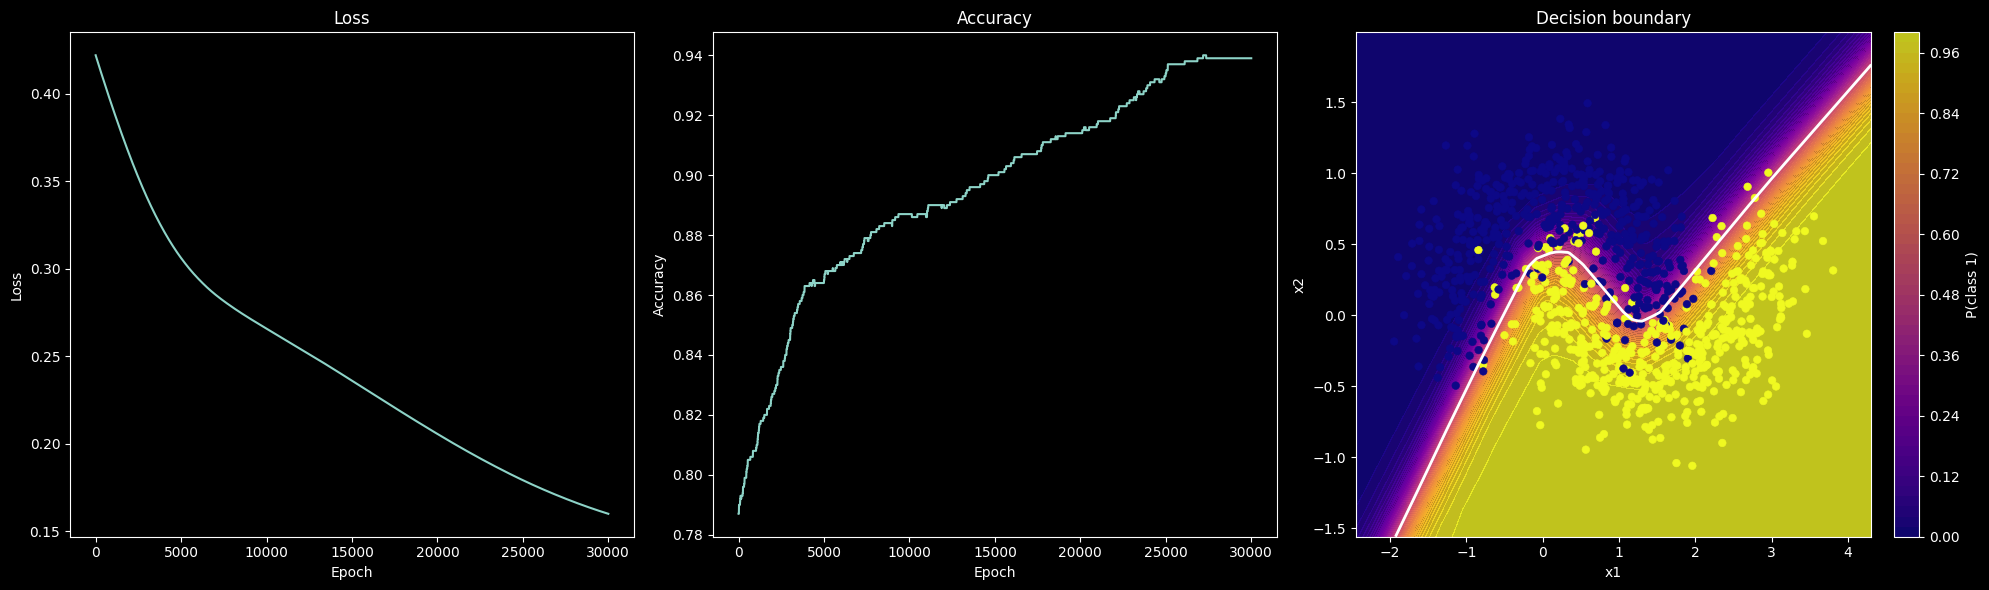

In [35]:
from modules.utils import plot_loss_acc_decision

fig, axs = plot_loss_acc_decision(X, y, loss_history, accuracy_history, model)

Avec PyTorch, on peut maintenant implémenter proprement tout ce qu’on a vu jusqu’ici :

* régression linéaire ;
* perceptron ;
* neurone avec activation ;
* couche dense ;
* MLP ;
* ANN.

Autrement dit, PyTorch nous donne enfin un cadre pratique pour construire des réseaux complets sans réécrire toute la mécanique à la main.